# Text as Data: TF-IDF and Document Similarity on SEC Filings

**Advanced Machine Learning for Finance — Lesson 1 Lab**  
University of Bologna, April–May 2026

---

## Objectives

This notebook applies the concepts from Lesson 1 to **real financial text**
drawn from the SEC EDGAR database:

1. **Corpus construction** — fetch 10-K annual filings from EDGAR for companies
   across different sectors.
2. **Preprocessing** — compare classical tokenization with subword (BPE)
   tokenization; examine the effect of stop-word removal, stemming, and
   lemmatization on the document-term matrix.
3. **TF-IDF representation** — build the sparse vector representation using
   scikit-learn and inspect which terms carry the most weight for each company.
4. **Document similarity** — compute and visualize cosine similarity; compare
   it with Euclidean distance to see why direction matters more than magnitude.
5. **Critical analysis** — identify where TF-IDF similarity matches human
   intuition (same-sector companies cluster together) and where it fails
   (semantic similarity without lexical overlap).

> **Data source:** All text is retrieved from the SEC EDGAR system
> ([https://www.sec.gov/edgar](https://www.sec.gov/edgar)), which is freely
> accessible for academic and research purposes.


---
## Part 0 — Setup and Dependencies


In [20]:
# Install dependencies (run once)
# !pip install requests beautifulsoup4 lxml scikit-learn matplotlib seaborn nltk tiktoken

import warnings
warnings.filterwarnings('ignore')

import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

# NLP / ML
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.decomposition import TruncatedSVD

# Text processing
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

print("All imports successful.")


All imports successful.


---
## Part 1 — Building a Corpus from SEC EDGAR

We retrieve the most recent 10-K annual filing for a set of companies drawn
from different sectors.  The goal is to have a corpus where:

- **same-sector** companies discuss similar topics and should have high
  TF-IDF similarity;
- **cross-sector** companies discuss different topics and should have low
  similarity.

This gives us a natural ground truth to evaluate the representation.

### Company selection

| Ticker | Company | Sector |
|--------|---------|--------|
| JPM | JPMorgan Chase | Banking |
| GS | Goldman Sachs | Banking |
| BAC | Bank of America | Banking |
| AAPL | Apple | Technology |
| MSFT | Microsoft | Technology |
| GOOGL | Alphabet | Technology |
| XOM | ExxonMobil | Energy |
| CVX | Chevron | Energy |
| PFE | Pfizer | Healthcare |
| JNJ | Johnson & Johnson | Healthcare |
| KO | Coca-Cola | Consumer Staples |
| PG | Procter & Gamble | Consumer Staples |


In [21]:
import requests
from bs4 import BeautifulSoup

# ── SEC EDGAR requires a User-Agent header ──────────────────────
HEADERS = {
    'User-Agent': 'UniversityOfBologna research@unibo.it',
    'Accept-Encoding': 'gzip, deflate',
}

# ── Company CIK numbers (Central Index Key) ─────────────────────
COMPANIES = {
    'JPM':   {'cik': 19617,   'sector': 'Banking'},
    'GS':    {'cik': 886982,  'sector': 'Banking'},
    'BAC':   {'cik': 70858,   'sector': 'Banking'},
    'AAPL':  {'cik': 320193,  'sector': 'Technology'},
    'MSFT':  {'cik': 789019,  'sector': 'Technology'},
    'GOOGL': {'cik': 1652044, 'sector': 'Technology'},
    'XOM':   {'cik': 34088,   'sector': 'Energy'},
    'CVX':   {'cik': 93410,   'sector': 'Energy'},
    'PFE':   {'cik': 78003,   'sector': 'Healthcare'},
    'JNJ':   {'cik': 200406,  'sector': 'Healthcare'},
    'KO':    {'cik': 21344,   'sector': 'Consumer'},
    'PG':    {'cik': 80424,   'sector': 'Consumer'},
}

print(f"Corpus will consist of {len(COMPANIES)} companies across "
      f"{len(set(c['sector'] for c in COMPANIES.values()))} sectors.")


Corpus will consist of 12 companies across 5 sectors.


### 1.1 — Fetching Filing Metadata from EDGAR

We use the EDGAR submissions API to find the most recent 10-K filing
for each company.


In [22]:
def get_latest_10k_url(cik):
    '''Fetch the most recent 10-K filing URL from EDGAR.'''
    url = f"https://data.sec.gov/submissions/CIK{cik:010d}.json"
    resp = requests.get(url, headers=HEADERS)
    resp.raise_for_status()
    data = resp.json()

    recent = data['filings']['recent']
    forms = recent['form']
    accessions = recent['accessionNumber']
    primary_docs = recent['primaryDocument']

    for i, form in enumerate(forms):
        if form == '10-K':
            acc = accessions[i].replace('-', '')
            doc = primary_docs[i]
            filing_url = (f"https://www.sec.gov/Archives/edgar/data/"
                          f"{cik}/{acc}/{doc}")
            return filing_url, accessions[i]

    return None, None


# ── Retrieve filing URLs ────────────────────────────────────────
filing_urls = {}
for ticker, info in COMPANIES.items():
    url, accession = get_latest_10k_url(info['cik'])
    filing_urls[ticker] = url
    status = "✓" if url else "✗ not found"
    print(f"  {ticker:6s} ({info['sector']:12s})  {status}")
    time.sleep(0.12)  # SEC rate limit: max 10 req/sec

print(f"\nFound {sum(1 for v in filing_urls.values() if v)} / "
      f"{len(filing_urls)} filings.")


  JPM    (Banking     )  ✓
  GS     (Banking     )  ✓
  BAC    (Banking     )  ✓
  AAPL   (Technology  )  ✓
  MSFT   (Technology  )  ✓
  GOOGL  (Technology  )  ✓
  XOM    (Energy      )  ✓
  CVX    (Energy      )  ✓
  PFE    (Healthcare  )  ✓
  JNJ    (Healthcare  )  ✓
  KO     (Consumer    )  ✓
  PG     (Consumer    )  ✓

Found 12 / 12 filings.


### 1.2 — Downloading and Extracting Text

10-K filings are typically large HTML documents.  We download each filing,
strip the HTML tags, and keep only the text.

For this exercise we **truncate** each document to approximately 20,000
characters (roughly the first 15–20 pages).  This keeps the corpus
manageable while retaining the most descriptive sections of the filing
(typically the business description and risk factors).


In [5]:
def extract_text_from_filing(url, max_chars=20_000):
    '''Download a 10-K filing and extract clean text.'''
    try:
        resp = requests.get(url, headers=HEADERS, timeout=30)
        resp.raise_for_status()
    except Exception as e:
        print(f"    ⚠ Download failed: {e}")
        return None

    soup = BeautifulSoup(resp.content, 'lxml')

    # Remove script, style, and table elements
    for tag in soup(['script', 'style', 'table', 'ix:nonfraction',
                     'ix:nonnumeric']):
        tag.decompose()

    text = soup.get_text(separator=' ')

    # Clean whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Truncate
    if len(text) > max_chars:
        text = text[:max_chars]

    return text


# ── Download and extract ────────────────────────────────────────
corpus = {}
for ticker, url in filing_urls.items():
    if url is None:
        continue
    print(f"  Downloading {ticker}...", end=' ')
    text = extract_text_from_filing(url)
    if text and len(text) > 1000:
        corpus[ticker] = text
        print(f"{len(text):,} chars")
    else:
        print("⚠ too short or failed")
    time.sleep(0.15)

print(f"\n{'='*50}")
print(f"Corpus ready: {len(corpus)} documents")
for ticker, text in corpus.items():
    sector = COMPANIES[ticker]['sector']
    print(f"  {ticker:6s} ({sector:12s}): {len(text):>7,} chars, "
          f"{len(text.split()):>5,} tokens (approx)")



Corpus ready: 12 documents
  JPM    (Banking     ):  20,000 chars,   796 tokens (approx)
  GS     (Banking     ):  20,000 chars,   831 tokens (approx)
  BAC    (Banking     ):  20,000 chars,   972 tokens (approx)
  AAPL   (Technology  ):  20,000 chars, 1,811 tokens (approx)
  MSFT   (Technology  ):  20,000 chars, 1,026 tokens (approx)
  GOOGL  (Technology  ):  20,000 chars,   914 tokens (approx)
  XOM    (Energy      ):  20,000 chars, 1,159 tokens (approx)
  CVX    (Energy      ):  20,000 chars,   989 tokens (approx)
  PFE    (Healthcare  ):  20,000 chars, 1,095 tokens (approx)
  JNJ    (Healthcare  ):  20,000 chars, 1,015 tokens (approx)
  KO     (Consumer    ):  20,000 chars, 1,011 tokens (approx)
  PG     (Consumer    ):  20,000 chars, 1,059 tokens (approx)


---
## Part 2 — Preprocessing: Choices and Consequences

Preprocessing is often presented as a "standard pipeline", but in practice
every step involves a decision that can change the downstream result.
We explore three dimensions of choice:

1. **Tokenization**: classical word-level vs. subword (BPE)
2. **Normalization**: with/without stop-word removal, stemming, lemmatization
3. **Effect on the vocabulary**: how each choice changes the feature space


### 2.1 — Classical vs. BPE Tokenization

We compare how classical word-level tokenization and BPE (as used by GPT-4)
segment typical financial text.


In [6]:
# ── Pick a sample sentence from the corpus ──────────────────────
sample_ticker = list(corpus.keys())[0]
# Find a reasonably interesting sentence
sentences = corpus[sample_ticker].split('.')
sample_sentence = None
for s in sentences:
    words = s.strip().split()
    if 15 < len(words) < 40 and any(w[0].isupper() for w in words[1:]):
        sample_sentence = s.strip() + '.'
        break

if sample_sentence is None:
    sample_sentence = '. '.join(sentences[3:5]).strip()

print(f"Sample sentence from {sample_ticker} 10-K:\n")
print(f'  "{sample_sentence[:200]}..."' if len(sample_sentence)>200
      else f'  "{sample_sentence}"')


Sample sentence from JPM 10-K:

  "75NonCumulativePreferredStockSeriesGGMember 2025-01-01 2025-12-31 0000019617 jpm:DepositarySharesOneFourHundredthInterestInAShareOf455NonCumulativePreferredStockSeriesJJMember 2025-01-01 2025-12-31 00..."


In [7]:
# ── Classical tokenization ───────────────────────────────────────
classical_tokens = word_tokenize(sample_sentence.lower())
print(f"Classical tokenization ({len(classical_tokens)} tokens):")
print(f"  {classical_tokens[:25]}")

# ── BPE tokenization (GPT-4 tokenizer) ─────────────────────────
try:
    import tiktoken
    enc = tiktoken.encoding_for_model("gpt-4")
    bpe_token_ids = enc.encode(sample_sentence)
    bpe_tokens = [enc.decode([t]) for t in bpe_token_ids]
    print(f"\nBPE tokenization ({len(bpe_tokens)} tokens):")
    print(f"  {bpe_tokens[:25]}")

    print(f"\n── Comparison ──────────────────────────────")
    print(f"  Classical: {len(classical_tokens):>4} tokens")
    print(f"  BPE:       {len(bpe_tokens):>4} tokens")
except ImportError:
    print("\n⚠ tiktoken not installed. Install with: pip install tiktoken")


Classical tokenization (1480 tokens):
  ['75noncumulativepreferredstockseriesggmember', '2025-01-01', '2025-12-31', '0000019617', 'jpm', ':', 'depositarysharesonefourhundredthinterestinashareof455noncumulativepreferredstockseriesjjmember', '2025-01-01', '2025-12-31', '0000019617', 'jpm', ':', 'depositarysharesonefourhundredthinterestinashareof4625noncumulativepreferredstockseriesllmember', '2025-01-01', '2025-12-31', '0000019617', 'jpm', ':', 'depositarysharesonefourhundredthinterestinashareof420noncumulativepreferredstockseriesmmmember', '2025-01-01', '2025-12-31', '0000019617', 'jpm', ':', 'guaranteeofcallablefixedratenotesduejune102032ofjpmorganchasefinancialcompanyllcmember']

BPE tokenization (6656 tokens):
  ['75', 'Non', 'Cum', 'ulative', 'Preferred', 'Stock', 'Series', 'GG', 'Member', ' ', '202', '5', '-', '01', '-', '01', ' ', '202', '5', '-', '12', '-', '31', ' ', '000']

── Comparison ──────────────────────────────
  Classical: 1480 tokens
  BPE:       6656 tokens


#### Observation

BPE produces a different number of tokens and handles financial terms
(tickers, acronyms, numbers) in ways that may surprise:

- Numbers like `$12,345.67` are split into arbitrary fragments
- Acronyms like `EBITDA` become `EB|IT|DA`
- This is one reason why LLMs struggle with arithmetic and precise entity matching


### 2.2 — The Effect of Preprocessing Choices

We now build four different versions of the corpus to see how preprocessing
choices affect the document-term matrix.


In [8]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


def preprocess(text, remove_stops=False, do_stem=False, do_lemma=False):
    '''Tokenize and optionally normalize text.'''
    # Lowercase and tokenize
    tokens = word_tokenize(text.lower())
    # Keep only alphabetic tokens
    tokens = [t for t in tokens if t.isalpha() and len(t) > 2]
    if remove_stops:
        tokens = [t for t in tokens if t not in stop_words]
    if do_stem:
        tokens = [stemmer.stem(t) for t in tokens]
    elif do_lemma:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


# ── Build four versions of the corpus ───────────────────────────
tickers = sorted(corpus.keys())
raw_docs = [corpus[t] for t in tickers]

versions = {
    'raw':          [preprocess(d) for d in raw_docs],
    'no_stopwords': [preprocess(d, remove_stops=True) for d in raw_docs],
    'stemmed':      [preprocess(d, remove_stops=True, do_stem=True)
                     for d in raw_docs],
    'lemmatized':   [preprocess(d, remove_stops=True, do_lemma=True)
                     for d in raw_docs],
}

# ── Compare vocabulary sizes ────────────────────────────────────
print(f"{'Version':<16} {'Vocab size':>12} {'Avg tokens/doc':>16}")
print("─" * 48)
for name, docs in versions.items():
    all_tokens = ' '.join(docs).split()
    vocab = set(all_tokens)
    avg_len = np.mean([len(d.split()) for d in docs])
    print(f"{name:<16} {len(vocab):>12,} {avg_len:>16,.0f}")


Version            Vocab size   Avg tokens/doc
────────────────────────────────────────────────
raw                       820              520
no_stopwords              790              503
stemmed                   750              503
lemmatized                773              503


#### Key takeaway

Each preprocessing step **reduces** the vocabulary size — this is a form of
information compression.  Stop-word removal is the most aggressive single step;
stemming further collapses lexical variants.

The question is always: **does the removed information matter for the task?**
For document-level similarity, removing stop words typically helps.  But for
sentiment analysis, removing "not" can invert the meaning of a sentence.


---
## Part 3 — TF-IDF Representation

We build the TF-IDF matrix using the **lemmatized, stop-word-free** version
of the corpus — the version that best balances vocabulary reduction with
semantic preservation.


In [9]:
# ── Build TF-IDF matrix ──────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=5000,     # keep top 5000 terms
    min_df=2,              # term must appear in at least 2 docs
    max_df=0.95,           # ignore terms in >95% of docs
    sublinear_tf=False,    # raw TF (no log), to match lecture
    norm='l2',             # L2 normalization (standard)
)

docs_for_tfidf = versions['lemmatized']
tfidf_matrix = tfidf.fit_transform(docs_for_tfidf)
feature_names = tfidf.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"  {tfidf_matrix.shape[0]} documents × {tfidf_matrix.shape[1]} terms")
print(f"  Density: {tfidf_matrix.nnz / np.prod(tfidf_matrix.shape):.2%}")
print(f"  (i.e., {100 - tfidf_matrix.nnz / np.prod(tfidf_matrix.shape)*100:.1f}%"
      f" of entries are zero — this is a sparse representation)")


TF-IDF matrix shape: (12, 103)
  12 documents × 103 terms
  Density: 29.69%
  (i.e., 70.3% of entries are zero — this is a sparse representation)


### 3.1 — Most Distinctive Terms per Company

For each document (company), we extract the terms with the highest TF-IDF
weight.  These are terms that are **frequent in that document** but
**relatively rare across the corpus** — exactly the terms that make the
document distinctive.


In [11]:
def top_tfidf_terms(matrix, feature_names, doc_index, n=10):
    '''Return the top-n TF-IDF terms for a given document.'''
    row = matrix[doc_index].toarray().flatten()
    top_idx = row.argsort()[::-1][:n]
    return [(feature_names[i], round(row[i], 3)) for i in top_idx]


# ── Display top terms per company ───────────────────────────────
print(f"{'Ticker':<8} {'Sector':<14} Top 8 TF-IDF terms")
print("─" * 80)
for i, ticker in enumerate(tickers):
    sector = COMPANIES[ticker]['sector']
    terms = top_tfidf_terms(tfidf_matrix, feature_names, i, n=8)
    term_str = ', '.join(f"{t}" for t, w in terms)
    print(f"{ticker:<8} {sector:<14} {term_str}")


Ticker   Sector         Top 8 TF-IDF terms
────────────────────────────────────────────────────────────────────────────────
AAPL     Technology     operatingsegmentsmember, security, period, restrictedstockunitsrsumember, commercialpapermember, country, commonstockincludingadditionalpaidincapitalmember, othercountriesmember
BAC      Banking        longmember, shortmember, designatedashedginginstrumentmember, nondesignatedmember, currencyswapmember, interestrateswapmember, preferredstockmember, commonstockincludingadditionalpaidincapitalmember
CVX      Energy         operatingsegmentsmember, fairvaluemeasurementsrecurringmember, intersegmenteliminationmember, nonusmember, commoditycontractmember, country, allothersegmentsmember, accumulatedgainlossnetcashflowhedgeparentmember
GOOGL    Technology     fairvaluemeasurementsrecurringmember, salesrevenuenetmember, banktimedepositsmember, corporatedebtsecuritiesmember, foreignexchangecontractmember, moneymarketfundsmember, commonstockincludin

#### Interpretation

Look at the results:
- Do **banking** companies share similar top terms (e.g., *loan*, *deposit*,
  *credit*, *interest*)?
- Do **technology** companies share different terms (e.g., *cloud*, *user*,
  *revenue*, *advertising*)?
- Are there terms that appear as "top" for companies in different sectors?
  What does that tell us about the specificity of TF-IDF?

> **This is the IDF mechanism at work**: terms like *revenue* or *operating*
> are common across all 10-K filings and receive low IDF weight.  Terms like
> *drilling* or *pharmaceutical* are sector-specific and receive high IDF weight.


---
## Part 4 — Document Similarity

Now we compute how similar each pair of documents is, using both cosine
similarity and Euclidean distance.  We expect to see a clear difference
in their behavior.


### 4.1 — Cosine Similarity Matrix


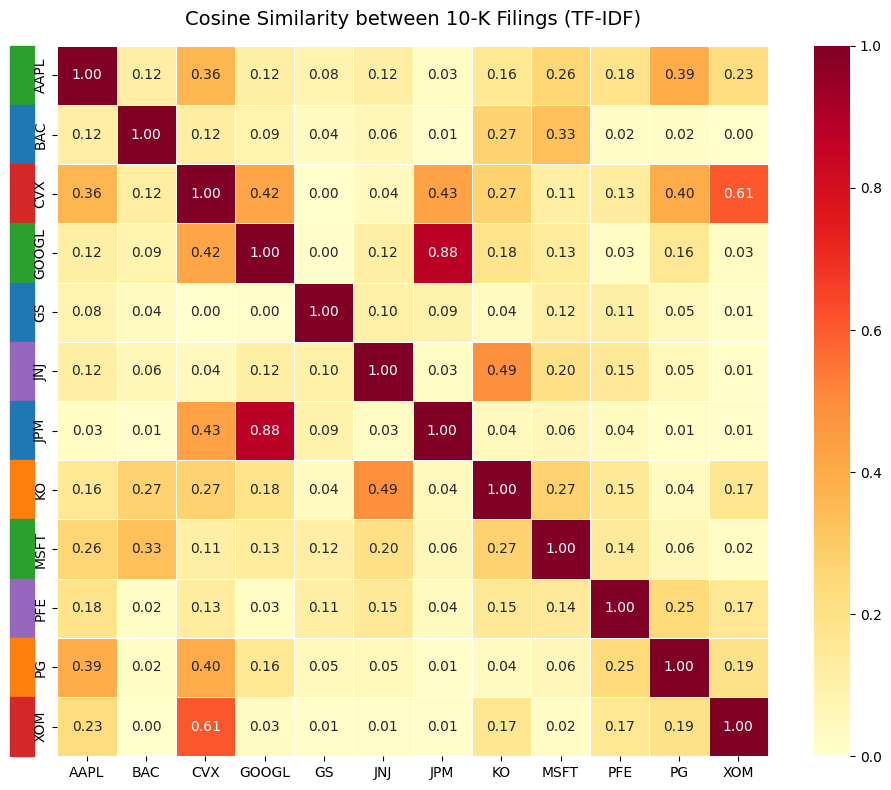

In [12]:
# ── Compute cosine similarity ────────────────────────────────────
cos_sim = cosine_similarity(tfidf_matrix)
cos_df = pd.DataFrame(cos_sim, index=tickers, columns=tickers)

# ── Assign colors by sector ─────────────────────────────────────
sector_colors = {
    'Banking':    '#1f77b4',
    'Technology': '#2ca02c',
    'Energy':     '#d62728',
    'Healthcare': '#9467bd',
    'Consumer':   '#ff7f0e',
}

row_colors = [sector_colors[COMPANIES[t]['sector']] for t in tickers]

# ── Heatmap ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cos_df, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, square=True, ax=ax,
            linewidths=0.5, linecolor='white')

ax.set_title('Cosine Similarity between 10-K Filings (TF-IDF)',
             fontsize=14, pad=15)

# Add sector color bar on the left
for i, color in enumerate(row_colors):
    ax.add_patch(plt.Rectangle((-0.8, i), 0.4, 1,
                               color=color, clip_on=False))

plt.tight_layout()
plt.show()


### 4.2 — Do Companies Cluster by Sector?

Let us check numerically whether same-sector pairs have higher similarity
than cross-sector pairs.


Average cosine similarity:
  Within sector:  0.160  (n = 9 pairs)
  Across sectors: 0.151  (n = 57 pairs)
  Ratio:          1.06x


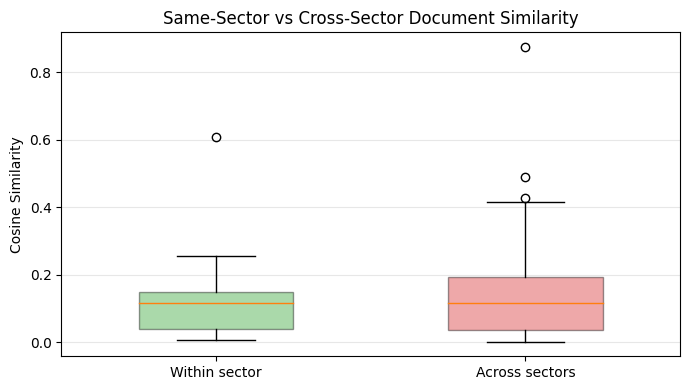

In [13]:
# ── Compute within-sector vs across-sector similarity ───────────
within_sector = []
across_sector = []

for i in range(len(tickers)):
    for j in range(i+1, len(tickers)):
        sim = cos_sim[i, j]
        if COMPANIES[tickers[i]]['sector'] == COMPANIES[tickers[j]]['sector']:
            within_sector.append(sim)
        else:
            across_sector.append(sim)

print(f"Average cosine similarity:")
print(f"  Within sector:  {np.mean(within_sector):.3f}  "
      f"(n = {len(within_sector)} pairs)")
print(f"  Across sectors: {np.mean(across_sector):.3f}  "
      f"(n = {len(across_sector)} pairs)")
print(f"  Ratio:          {np.mean(within_sector)/np.mean(across_sector):.2f}x")

# ── Boxplot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
data = [within_sector, across_sector]
bp = ax.boxplot(data, labels=['Within sector', 'Across sectors'],
                patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#2ca02c')
bp['boxes'][0].set_alpha(0.4)
bp['boxes'][1].set_facecolor('#d62728')
bp['boxes'][1].set_alpha(0.4)
ax.set_ylabel('Cosine Similarity')
ax.set_title('Same-Sector vs Cross-Sector Document Similarity')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### 4.3 — Euclidean Distance vs Cosine Similarity

Recall from the lecture that Euclidean distance conflates **what** a document
is about (direction) with **how long** it is (magnitude).  Let us verify this
empirically.


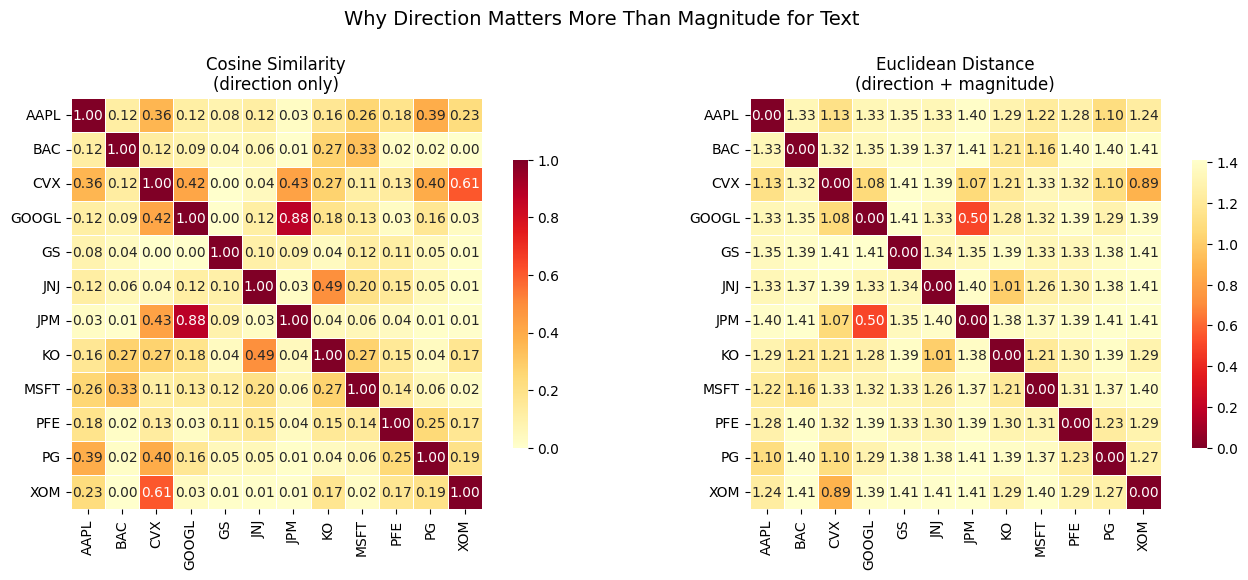

Rank correlation between cosine similarity and (-Euclidean): 0.989
(Should be high but not perfect — the two metrics do NOT always agree.)


In [14]:
# ── Compute Euclidean distances ──────────────────────────────────
euc_dist = euclidean_distances(tfidf_matrix)

# ── Compare the two metrics ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Cosine similarity
sns.heatmap(cos_df, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, square=True, ax=axes[0],
            linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.7})
axes[0].set_title('Cosine Similarity\n(direction only)', fontsize=12)

# Euclidean distance
euc_df = pd.DataFrame(euc_dist, index=tickers, columns=tickers)
sns.heatmap(euc_df, annot=True, fmt='.2f', cmap='YlOrRd_r',
            square=True, ax=axes[1],
            linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.7})
axes[1].set_title('Euclidean Distance\n(direction + magnitude)', fontsize=12)

plt.suptitle('Why Direction Matters More Than Magnitude for Text',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Correlation between the two ─────────────────────────────────
upper_cos = cos_sim[np.triu_indices_from(cos_sim, k=1)]
upper_euc = euc_dist[np.triu_indices_from(euc_dist, k=1)]
corr = np.corrcoef(upper_cos, -upper_euc)[0, 1]
print(f"Rank correlation between cosine similarity and (-Euclidean): {corr:.3f}")
print("(Should be high but not perfect — the two metrics do NOT always agree.)")


### 4.4 — Visualizing the Document Space

We reduce the TF-IDF vectors to 2 dimensions using Truncated SVD (a form of
dimensionality reduction related to PCA) to visualize how documents cluster.


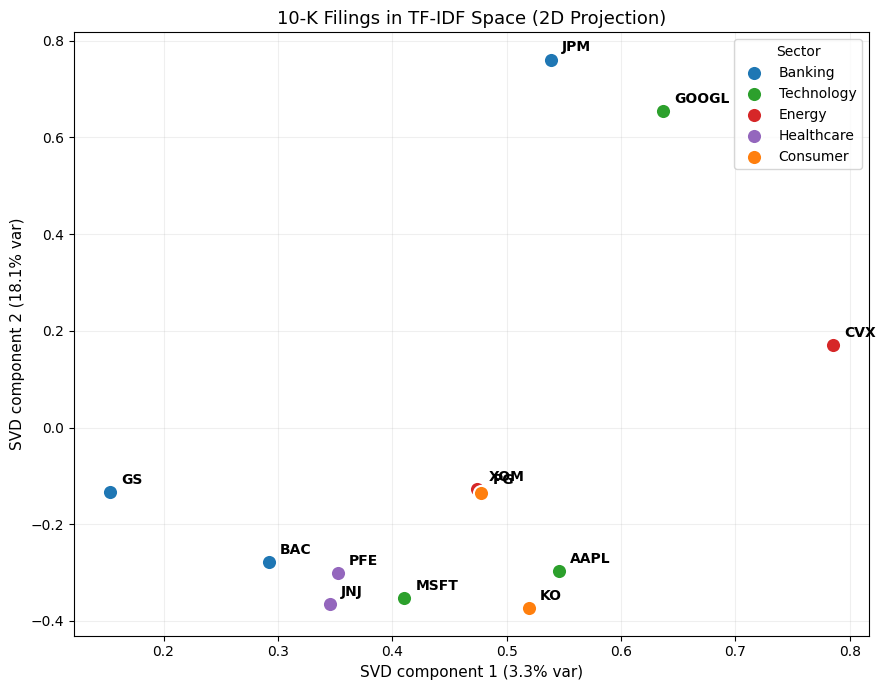

Total variance explained by 2 components: 21.4%


In [15]:
# ── 2D projection via Truncated SVD ─────────────────────────────
svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(tfidf_matrix)

fig, ax = plt.subplots(figsize=(9, 7))

for sector, color in sector_colors.items():
    mask = [COMPANIES[t]['sector'] == sector for t in tickers]
    idx = [i for i, m in enumerate(mask) if m]
    ax.scatter(coords[idx, 0], coords[idx, 1],
               c=color, s=120, label=sector, edgecolors='white',
               linewidth=1.5, zorder=3)
    for i in idx:
        ax.annotate(tickers[i], (coords[i, 0], coords[i, 1]),
                    fontsize=10, fontweight='bold',
                    xytext=(8, 6), textcoords='offset points')

ax.set_xlabel(f'SVD component 1 ({svd.explained_variance_ratio_[0]:.1%} var)',
              fontsize=11)
ax.set_ylabel(f'SVD component 2 ({svd.explained_variance_ratio_[1]:.1%} var)',
              fontsize=11)
ax.set_title('10-K Filings in TF-IDF Space (2D Projection)', fontsize=13)
ax.legend(title='Sector', loc='best', fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 components: "
      f"{svd.explained_variance_ratio_.sum():.1%}")


---
## Part 5 — Critical Analysis

A critical analysis is not optional — it is the most important part of the
exercise.  We ask: **where does TF-IDF similarity work well, and where does
it break down?**

### 5.1 — Where TF-IDF Succeeds


In [16]:
# ── Find the most similar pair within each sector ───────────────
print("Most similar pairs (within sector):")
print("─" * 60)

sectors = sorted(set(COMPANIES[t]['sector'] for t in tickers))

for sector in sectors:
    sector_tickers = [t for t in tickers if COMPANIES[t]['sector'] == sector]
    best_sim = -1
    best_pair = None
    for i, t1 in enumerate(sector_tickers):
        for t2 in sector_tickers[i+1:]:
            idx1 = tickers.index(t1)
            idx2 = tickers.index(t2)
            sim = cos_sim[idx1, idx2]
            if sim > best_sim:
                best_sim = sim
                best_pair = (t1, t2)
    if best_pair:
        print(f"  {sector:14s}  {best_pair[0]:5s} – {best_pair[1]:5s}  "
              f"cos = {best_sim:.3f}")


Most similar pairs (within sector):
────────────────────────────────────────────────────────────
  Banking         GS    – JPM    cos = 0.091
  Consumer        KO    – PG     cos = 0.039
  Energy          CVX   – XOM    cos = 0.608
  Healthcare      JNJ   – PFE    cos = 0.150
  Technology      AAPL  – MSFT   cos = 0.256


### 5.2 — Where TF-IDF Fails

TF-IDF similarity requires **lexical overlap**: two documents can only be
similar if they share the same words.  This creates systematic blind spots:


In [17]:
# ── Find surprising cross-sector similarities ───────────────────
print("Highest cross-sector similarities (potential false positives):")
print("─" * 65)

cross_pairs = []
for i in range(len(tickers)):
    for j in range(i+1, len(tickers)):
        if COMPANIES[tickers[i]]['sector'] != COMPANIES[tickers[j]]['sector']:
            cross_pairs.append((tickers[i], tickers[j], cos_sim[i, j]))

cross_pairs.sort(key=lambda x: x[2], reverse=True)

for t1, t2, sim in cross_pairs[:5]:
    s1 = COMPANIES[t1]['sector']
    s2 = COMPANIES[t2]['sector']
    print(f"  {t1:5s} ({s1:12s}) – {t2:5s} ({s2:12s})  cos = {sim:.3f}")

print("\n\nLowest within-sector similarities (potential false negatives):")
print("─" * 65)

within_pairs = []
for i in range(len(tickers)):
    for j in range(i+1, len(tickers)):
        if COMPANIES[tickers[i]]['sector'] == COMPANIES[tickers[j]]['sector']:
            within_pairs.append((tickers[i], tickers[j], cos_sim[i, j]))

within_pairs.sort(key=lambda x: x[2])

for t1, t2, sim in within_pairs[:3]:
    s1 = COMPANIES[t1]['sector']
    print(f"  {t1:5s} – {t2:5s} ({s1:12s})  cos = {sim:.3f}")


Highest cross-sector similarities (potential false positives):
─────────────────────────────────────────────────────────────────
  GOOGL (Technology  ) – JPM   (Banking     )  cos = 0.875
  JNJ   (Healthcare  ) – KO    (Consumer    )  cos = 0.490
  CVX   (Energy      ) – JPM   (Banking     )  cos = 0.427
  CVX   (Energy      ) – GOOGL (Technology  )  cos = 0.416
  CVX   (Energy      ) – PG    (Consumer    )  cos = 0.397


Lowest within-sector similarities (potential false negatives):
─────────────────────────────────────────────────────────────────
  BAC   – JPM   (Banking     )  cos = 0.007
  BAC   – GS    (Banking     )  cos = 0.036
  KO    – PG    (Consumer    )  cos = 0.039


### 5.3 — Shared Terms vs Missing Semantics

Let us look at a concrete pair of documents and understand **why** they
are (or are not) similar, by inspecting the terms that contribute most
to their cosine similarity.


In [18]:
def explain_similarity(t1, t2, matrix, feature_names, tickers, top_n=10):
    '''Show which terms drive similarity between two documents.'''
    i1 = tickers.index(t1)
    i2 = tickers.index(t2)

    v1 = matrix[i1].toarray().flatten()
    v2 = matrix[i2].toarray().flatten()

    # Element-wise product (contribution to dot product)
    contrib = v1 * v2
    top_idx = contrib.argsort()[::-1][:top_n]

    cos = cosine_similarity(matrix[i1], matrix[i2])[0, 0]

    print(f"\n{t1} vs {t2}  —  cosine similarity = {cos:.3f}")
    print(f"  Top terms driving similarity:")
    for idx in top_idx:
        if contrib[idx] > 0:
            print(f"    {feature_names[idx]:<20s}  "
                  f"w({t1})={v1[idx]:.3f}  w({t2})={v2[idx]:.3f}  "
                  f"product={contrib[idx]:.4f}")


# ── Explain a high-similarity pair ──────────────────────────────
if len(within_pairs) > 0:
    # Take the most similar within-sector pair
    best = max(within_pairs, key=lambda x: x[2])
    explain_similarity(best[0], best[1], tfidf_matrix, feature_names, tickers)

# ── Explain a low-similarity pair ───────────────────────────────
if len(cross_pairs) > 0:
    # Take a low cross-sector pair
    worst = min(cross_pairs, key=lambda x: x[2])
    explain_similarity(worst[0], worst[1], tfidf_matrix, feature_names, tickers)



CVX vs XOM  —  cosine similarity = 0.608
  Top terms driving similarity:
    nonusmember           w(CVX)=0.311  w(XOM)=0.708  product=0.2201
    intersegmenteliminationmember  w(CVX)=0.413  w(XOM)=0.374  product=0.1546
    country               w(CVX)=0.240  w(XOM)=0.554  product=0.1328
    operatingsegmentsmember  w(CVX)=0.514  w(XOM)=0.154  product=0.0792
    parentmember          w(CVX)=0.109  w(XOM)=0.077  product=0.0084
    noncontrollinginterestmember  w(CVX)=0.099  w(XOM)=0.070  product=0.0069
    treasurystockcommonmember  w(CVX)=0.083  w(XOM)=0.058  product=0.0048
    xbrli                 w(CVX)=0.026  w(XOM)=0.018  product=0.0005
    project               w(CVX)=0.020  w(XOM)=0.014  product=0.0003
    usd                   w(CVX)=0.017  w(XOM)=0.012  product=0.0002

BAC vs XOM  —  cosine similarity = 0.002
  Top terms driving similarity:
    commonstockmember     w(BAC)=0.010  w(XOM)=0.052  product=0.0005
    xbrli                 w(BAC)=0.027  w(XOM)=0.018  product=0.0005

### 5.4 — The Fundamental Limitation

TF-IDF similarity captures **lexical co-occurrence**, not **semantic meaning**.

Consider two hypothetical sentences:
- *"The company implemented a cost reduction program"*
- *"The firm executed an expense cutting initiative"*

A human reader immediately sees these are nearly identical in meaning.
But their TF-IDF vectors share **zero terms** (after stop-word removal),
so their cosine similarity is **exactly zero**.

This is the core limitation that motivates the transition to **dense
representations** (embeddings) — the topic of the next part of the
lecture.


In [19]:
# ── Demonstrate the semantic gap ─────────────────────────────────
pair_a = "The company implemented a cost reduction program to improve margins"
pair_b = "The firm executed an expense cutting initiative to boost profitability"

# Vectorize using the same TF-IDF vocabulary
v_a = tfidf.transform([preprocess(pair_a, remove_stops=True, do_lemma=True)])
v_b = tfidf.transform([preprocess(pair_b, remove_stops=True, do_lemma=True)])

sim = cosine_similarity(v_a, v_b)[0, 0]

print("Sentence A: " + pair_a)
print("Sentence B: " + pair_b)
print(f"\nCosine similarity (TF-IDF): {sim:.3f}")
print(f"\nA human would rate these as highly similar.")
print(f"TF-IDF says they are {'identical' if sim > 0.9 else 'similar' if sim > 0.3 else 'barely related' if sim > 0.05 else 'completely unrelated'}.")
print(f"\n→ This is the fundamental limitation that motivates dense embeddings.")


Sentence A: The company implemented a cost reduction program to improve margins
Sentence B: The firm executed an expense cutting initiative to boost profitability

Cosine similarity (TF-IDF): 0.000

A human would rate these as highly similar.
TF-IDF says they are completely unrelated.

→ This is the fundamental limitation that motivates dense embeddings.


---
## Summary and Connections

### What we have seen

1. **Real financial text** can be retrieved from SEC EDGAR and transformed
   into a structured corpus with standard Python tools.

2. **Preprocessing choices matter**: stop-word removal, stemming, and
   lemmatization each change the vocabulary and the resulting similarity
   structure.  There is no single "correct" pipeline — the right choice
   depends on the task.

3. **TF-IDF + cosine similarity** produces a meaningful document space:
   companies in the same sector tend to cluster together because they
   share domain-specific vocabulary (*loan*, *deposit* for banks;
   *cloud*, *user* for tech firms).

4. **Euclidean distance** is less appropriate for text vectors than cosine
   similarity because it conflates topic (direction) with document length
   (magnitude).

5. **TF-IDF has a fundamental limitation**: it captures lexical overlap,
   not semantic meaning.  Two documents can be highly related without
   sharing any words.

### What comes next

In Lesson 2 we will see how **dense representations** (word embeddings
and document embeddings) address the semantic gap.  The core idea is to
learn a low-dimensional space where words with similar *contexts* — not
just identical *forms* — receive similar vectors.

In Notebook 2 we will return to the retrieval problem and compare
TF-IDF retrieval with BM25 on this same corpus.
